# **Task notes**

<font size=2>The `PyHMMER` library (https://pyhmmer.readthedocs.io) is a strict equivalent of the `HMMER` tools (http://hmmer.org) and is based on their code. Before running any tool (e.g. `hmmsearch`), read its documentation, especially regarding the arguments that can be used and their meaning (http://eddylab.org/software/hmmer/Userguide.pdf, chapter `Manual pages for HMMER programs`).
</font>

## **1. Parsing files with HMM models**
- The `HMMFile` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/parsers.html)] object is dedicated to working with `*.hmm` files:
```Python
# Approach #1
with pyhmmer.plan7.HMMFile('HMM file path') as hmm_f:
    # ...

# Approach #2
hmm_f = pyhmmer.plan7.HMMFile('HMM file path')
# ...
hmm_f.close()
```
- The `HMMFile` object has a `read()` method, which each time reads and returns another model saved in the file as an `HMM` object [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/hmms.html#pyhmmer.plan7.HMM)]. The same effect is achieved by iterating over the open file:
```Python
for hmm in hmm_f:
    name = hmm.name.decode()
    accn = hmm.accession.decode()
    desc = hmm.description.decode()
    print(f'Model: {name} ({accn}), {desc}.')
```

## 2. **Parsing files with sequences in FASTA format**
- `SequenceFile` object [[doc](https://pyhmmer.readthedocs.io/en/stable/api/easel/parsers.html#pyhmmer.easel.SequenceFile)] can be used to parse FASTA files:
```Python
# Approach #1
with pyhmmer.easel.SequenceFile('FASTA file path', digital=True) as seq_f:
    # ...

# Approach #2
seq_f = pyhmmer.easel.SequenceFile('FASTA file path', digital=True)
# ...
seq_f.close()
```
- The `SequenceFile` object has a `read()` method, which each time reads and returns the next model saved in the file as a `Sequence` object [[doc](https://pyhmmer.readthedocs.io/en/stable/api/easel/seq.html#pyhmmer.easel.Sequence)]. Exactly the same effect is achieved by iterating over an open file:
```Python
for seq in seq_f:
    seqid = seq.name.decode()
    title = seq.description.decode()
    print(f'Sequence: {seqid} ({title}).')
```
- The `write()` method can be used to save a sequence (in binary mode) to a selected file:
```Python
with open('FASTA file path', 'wb') as faa_f:
    seq.write(faa_f)
```

## 3. **Using HMMER tools**
- Functions such as `hmmsearch()` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/hmmer/profile.html#pyhmmer.hmmer.hmmsearch)] or `hmmscan()` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/hmmer/profile.html#pyhmmer.hmmer.hmmscan)], which are equivalent HMMER tools with exactly the same name, return an object of type `TopHits` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/results.html#pyhmmer.plan7.TopHits)] over which you can iterate:
```Python
for hits in pyhmmer.hmmsearch(hmm, seq_f, cpus=8, E=0.01):
    # ...
```
- In each iteration, an object of the type `Hit` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/results.html#pyhmmer.plan7.Hit)] is returned, referring to one amino acid sequence from the database, which contains, among others, information about the sequence itself (`name`, `description`):
```Python
    for hit in hits:
        seqid = hit.name.decode()
        title = hit.description.decode()
        print(f'Target sequence: {seqid} ({title})')
        # ...
```
- The `Hit` object also contains information about sequence-matched domains in an object of type `Domains` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/results.html#pyhmmer.plan7.Domains)], which is also iterable. In the iteration process, we obtain objects of type `Domain` [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/results.html#pyhmmer.plan7.Domain)]:
```Python
        for dom in hit.domains:
            i_eval = dom.i_evalue
            env_from = home.env_from
            env_to = home.env_to
            print(f'Domain envelope coordinates in the target sequence: {env_from}-{env_to}')
            print(f'Domain hit independent E_value: {i_eval}')
```
- Each `Domain` object also contains an `Alignment` object [[doc](https://pyhmmer.readthedocs.io/en/stable/api/plan7/results.html#pyhmmer.plan7.Alignment)], which contains more detailed information about the alignment between the database sequence fragment and the domain HMM:
```Python
            hmm_len = dom.alignment.hmm_length
            hmm_from = dom.alignment.hmm_from
            hmm_to = dom.alignment.hmm_to
            
            seq_len = dom.alignment.target_length
            seq_from = dom.alignment.target_from
            seq_to = dom.alignment.target_to
            
            print(f'Aligned HMM length: {hmm_len}, aligned portion: {hmm_from}-{hmm_to}')
            print(f'Aligned sequence length: {seq_len}, aligned portion: {seq_from}-{seq_to}')
```
- Based on the above coordinates, we can easily calculate the coverage of the domain model by the matched fragment of the amino acid sequence:
$${cov} = \frac {|to - from| + 1} {length} $$

# **Task**

NOTE: <u>all</u> of the following steps should be implemented <u>in this notebook</u>:
1. Use the appropriate Bash commands (`mkdir -p` and `wget`) to create the `output/` and `dbs/` directories, and for the latter, download the Pfam database (`Pfam-A.hmm`) from the `InterPro` website [[here](https://www.ebi.ac.uk/interpro)]. Perform the next steps using the `PyHMMER` library.
3. Search the Pfam database (`Pfam-A.hmm`) for a model called `Peptidase_M23` with the accession number (accn) `PF01551` (in the database these will be numbers with the version, i.e. in the `accn.ver` format).
5. Use this model to search all sequences found in all FASTA files in the `prots/` directory. Here you can use the benefits of the `Path` class from the `pathlib` library and the `glob()` method [[doc](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob)] of objects of this type.
6. Consider only those matches that cover a significant portion of the domain model &mdash; `cov` &ge; `90%` &mdash; and whose `iE-value` &le; `0.01`.
7. Extract sequences containing such matches into a separate FASTA file `output/extracted.faa`.
8. Search the extracted sequences against the entire Pfam database. Use the same 'coverage' and 'iE-value' criteria as described earlier.
9. Calculate the <u>frequencies</u> of the `Peptidase_M23` domain with other domains in the analyzed amino acid sequences. Include the frequency of the `Peptidase_M23` domain as the only domain in the database amino acid sequences.
10. Using the `Matplotlib` library, display the obtained values ​​on a bar chart, the bars of which will be signed with domain names (X-tick labels) rotated by 45&deg;.

In [ ]:
!mkdir -p output dbs
!wget -P dbs ftp://ftp.ebi.ac.uk/pub/databases/Pfam/current_release/Pfam-A.hmm.gz
!gunzip /dbs/Pfam-A.hmm.gz

In [44]:
import pyhmmer
from pathlib import Path

target_model_hmm = None
target_model_name = "Peptidase_M23"
target_model_accn = "PF01551"

with pyhmmer.plan7.HMMFile("dbs/Pfam-A.hmm") as hmm_f:
    for hmm in hmm_f:
        if hmm.name.decode() == target_model_name and hmm.accession.decode().startswith(target_model_accn):
            print(f"Name: {hmm.name.decode()}, Accession number: {hmm.accession.decode()}")
            target_model_hmm = hmm 
            break 

Name: Peptidase_M23, Accession number: PF01551.30


In [45]:
prots_dir = Path("prots")
seq_files = list(prots_dir.glob("*.faa"))
all_sequences = []

for file_path in seq_files:
    with pyhmmer.easel.SequenceFile(file_path, digital=True) as seq_f:
        all_sequences.extend(seq_f)

In [ ]:
top_hits = pyhmmer.hmmsearch(target_model_hmm, all_sequences, cpus=8, E=0.01)

hit_sequence_names = set()

for hits in top_hits:
    for hit in hits:
        for dom in hit.domains:
            if dom.i_evalue <= 0.01:
                coverage = (abs(dom.alignment.hmm_to - dom.alignment.hmm_from) + 1) / dom.alignment.hmm_length
                if coverage > 0.9:
                    hit_sequence_names.add(hit.name) 
                    break

print(f"# of found sequences: {len(hit_sequence_names)}")
print(f"All sequences in total: {len(all_sequences)}")

In [47]:
hit_sequences = [seq for seq in all_sequences if seq.name in hit_sequence_names]

with open("output/extracted.faa", "w") as output_f:
    for seq in hit_sequences:
        text_seq = seq.textize()
        output_f.write(f">{text_seq.name.decode()}\n") 
        output_f.write(f"{text_seq.sequence}\n")

In [ ]:
with pyhmmer.plan7.HMMFile("dbs/Pfam-A.hmm") as hmm_f:
    all_hmms = list(hmm_f)

print(f"Loaded {len(all_hmms)} HMMs")

extracted_seqs = []
with pyhmmer.easel.SequenceFile("output/extracted.faa", digital=True) as seq_f:
    extracted_seqs.extend(seq_f)

print(f"Number of sequences in extracted file: {len(extracted_seqs)}")

all_hits = pyhmmer.hmmsearch(all_hmms, extracted_seqs, cpus=8)

In [ ]:
sequence_domains = {}

for hits in all_hits:
    query_name = hits.query.name.decode()
    for hit in hits:
        seq_name = hit.name
        for dom in hit.domains:
            if dom.i_evalue <= 0.01:
                coverage = (abs(dom.alignment.hmm_to - dom.alignment.hmm_from) + 1) / dom.alignment.hmm_length
                if coverage > 0.9:
                    if seq_name not in sequence_domains:
                        sequence_domains[seq_name] = set()
                    sequence_domains[seq_name].add(query_name)
                    break

domain_counts = {}
for seq_name, domains in sequence_domains.items():
    for domain in domains:
        if domain not in domain_counts:
            domain_counts[domain] = 0
        domain_counts[domain] += 1

sorted_domains = sorted(domain_counts.items(), key=lambda x: x[1], reverse=True)

print(f"Domain name: number of occurrences z Peptidase_M23:")
for domain, count in sorted_domains:
    print(f"{domain}: {count}")

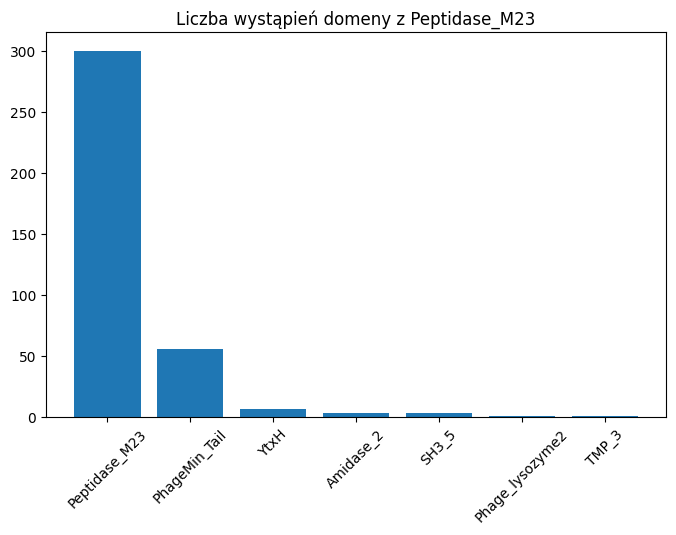

In [50]:
import matplotlib.pyplot as plt

domains = [dom[0] for dom in sorted_domains]
counts = [dom[1] for dom in sorted_domains]

plt.figure(figsize=(8, 5))
plt.bar(range(len(domains)), counts)
plt.xticks(range(len(domains)), domains, rotation=45)
plt.title('Number of domain occurrences z Peptidase_M23')
plt.show()